In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

In [2]:
import matplotlib.pyplot as plt
sc.settings.figdir="../results/figures"

In [3]:
adata = sc.read_h5ad('../data/raw/GSE131907_Lung_Cancer_raw_with_metadata.h5ad')

/opt/miniconda3/envs/singlecell/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [4]:
adata

AnnData object with n_obs × n_vars = 208506 × 29634
    obs: 'index', 'title', 'sample', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.patient id', 'characteristics_ch1.1.tumor stage', 'characteristics_ch1.2.tissue origin abbrevation', 'characteristics_ch1.3.lung cancer subtype', 'growth_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'description', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_phone', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_zip/postal_code', 'contact_country', 'instrument_model', 'library_selection', 'library_source', 'library_strategy', 'relation', 'supplementary_file_1', 'series_id', 'data_row_count'

In [5]:
#preserve raw counts first 
adata.layers['counts']=adata.X.copy()

In [6]:
#QC metrics
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata,qc_vars=['mt'],inplace=True)

In [7]:
adata.obs

,index,title,sample,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,...,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
0,AAACCTGAGAAACCGC_LN_05,LN_05,GSM3827151,Public on Mar 27 2020,May 29 2019,Aug 18 2021,SRA,1,Normal lymph node,Homo sapiens,...,7.433075,19928.0,9.899931,84.017463,87.354476,90.074267,93.692292,43.0,3.784190,0.215777
1,AAACCTGAGAAACGCC_NS_13,NS_13,GSM3827168,Public on Mar 27 2020,May 29 2019,Aug 18 2021,SRA,1,Metastatic brain,Homo sapiens,...,6.416732,1382.0,7.232010,55.499276,62.735166,70.260492,91.968162,171.0,5.147494,12.373372
2,AAACCTGAGAAGGTGA_LUNG_N18,LUNG_N18,GSM3827118,Public on Mar 27 2020,May 29 2019,Aug 02 2022,SRA,1,Normal lung,Homo sapiens,...,7.015712,3214.0,8.075583,37.678905,53.453640,66.677038,80.927194,106.0,4.672829,3.298071
3,AAACCTGAGACAAAGG_LUNG_N18,LUNG_N18,GSM3827118,Public on Mar 27 2020,May 29 2019,Aug 02 2022,SRA,1,Normal lung,Homo sapiens,...,7.003974,2990.0,8.003363,36.254181,51.471572,64.949833,79.933110,133.0,4.897840,4.448161
4,AAACCTGAGACATAAC_LN_04,LN_04,GSM3827150,Public on Mar 27 2020,May 29 2019,Aug 18 2021,SRA,1,Normal lymph node,Homo sapiens,...,6.855409,3880.0,8.263848,53.427835,69.948454,79.046392,88.453608,76.0,4.343805,1.958763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208501,TTTGTCATCTTGCCGT_LUNG_T30,LUNG_T30,GSM3827133,Public on Mar 27 2020,May 29 2019,Aug 02 2022,SRA,1,Tumour lung,Homo sapiens,...,7.716906,7981.0,8.984944,41.360732,50.582634,60.593911,73.925573,198.0,5.293305,2.480892
208502,TTTGTCATCTTGTATC_EFFUSION_13,EFFUSION_13,GSM3827160,Public on Mar 27 2020,May 29 2019,Aug 18 2021,SRA,1,Pleural effusion,Homo sapiens,...,7.090077,4113.0,8.322151,46.146365,61.876975,72.380258,83.005106,114.0,4.744932,2.771699
208503,TTTGTCATCTTTACAC_LUNG_N20,LUNG_N20,GSM3827120,Public on Mar 27 2020,May 29 2019,Aug 02 2022,SRA,1,Normal lung,Homo sapiens,...,6.727432,1979.0,7.590852,38.706417,52.956038,65.891865,83.122789,97.0,4.584968,4.901465
208504,TTTGTCATCTTTACAC_LUNG_T25,LUNG_T25,GSM3827131,Public on Mar 27 2020,May 29 2019,Aug 02 2022,SRA,1,Tumour lung,Homo sapiens,...,6.826545,3342.0,8.114624,49.670856,66.277678,76.810293,87.402753,94.0,4.553877,2.812687


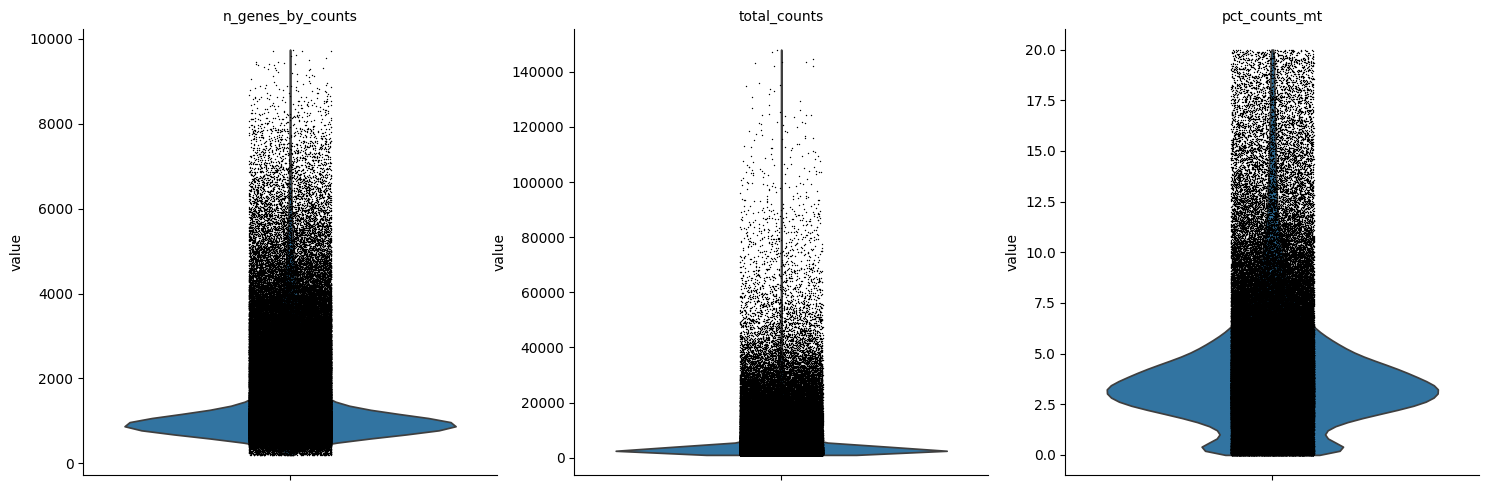

In [8]:
#visualization before filtering 
sc.pl.violin(adata,['n_genes_by_counts','total_counts','pct_counts_mt'],multi_panel=True,save='_qc_before_filtering.png')

In [9]:
#filtering 
sc.pp.filter_cells(adata,min_genes=200)
adata=adata[adata.obs['n_genes_by_counts']<7000,:].copy()
adata=adata[adata.obs['pct_counts_mt']<10,:].copy()
sc.pp.filter_genes(adata,min_cells=3)

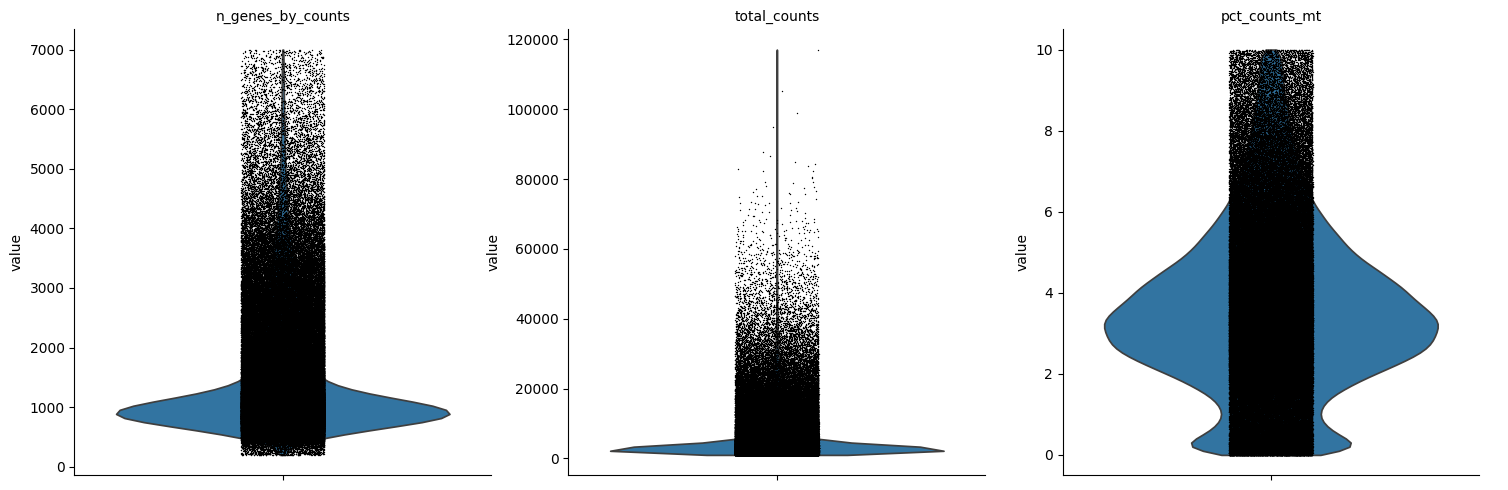

In [10]:
#After filtering 
sc.pl.violin(adata,['n_genes_by_counts','total_counts','pct_counts_mt'],multi_panel=True,save='_qc_after_filtering.png')

In [11]:
adata.write("../data/processed/nsclc_qc.h5ad")